# Statistical Modeling and Inferencing — Assignment 1 (2025–26)

**Name:** Shobha Madhavaiah
**Roll Number:**  2025em1200339@bitspilani-digital.edu.in
**Chosen Dataset:** Mall Customer Segmentation Dataset (Clustering)  
**Submission Date:** 12-Apr-2026  

**Colab Link (Anyone with link can view):** <PASTE YOUR COLAB VIEW LINK HERE>

## Summary

This notebook performs customer segmentation using the Mall Customer Segmentation dataset. The objective is to identify natural groupings of customers based on demographic and behavioral indicators (Gender, Age, Annual Income, Spending Score) using unsupervised clustering.

The workflow includes: (1) exploratory data analysis (EDA) with descriptive statistics and visualizations, correlation analysis, and data quality checks (missing values and outliers); (2) clustering model development using both K-Means and Hierarchical clustering; selection of the optimal number of clusters using Elbow and Silhouette methods; cluster quality evaluation through silhouette plots and stability checks; and (3) interpretation of cluster profiles with actionable business insights, limitations, and recommendations.

Part 1: Data Exploration and Preparation—  (Imports)

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import zscore

sns.set(style="whitegrid")
np.random.seed(42)

In [41]:
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [42]:
print("Shape:", df.shape)
display(df.info())
display(df.isna().sum())

# Numeric summary (works in older pandas too)
display(df.select_dtypes(include=[np.number]).describe())

# Categorical summary
display(df.select_dtypes(include=["object"]).describe())

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


,Gender
count,200
unique,2
top,Female
freq,112


In [43]:
df = df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
})
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Understanding
- **CustomerID**: identifier (not meaningful for clustering).
- **Gender**: categorical.
- **Age**: numeric.
- **AnnualIncome (k$)**: numeric (income proxy).
- **SpendingScore (1–100)**: numeric (behavior proxy).

Clustering will be performed using distance-based methods, so **scaling** is required.

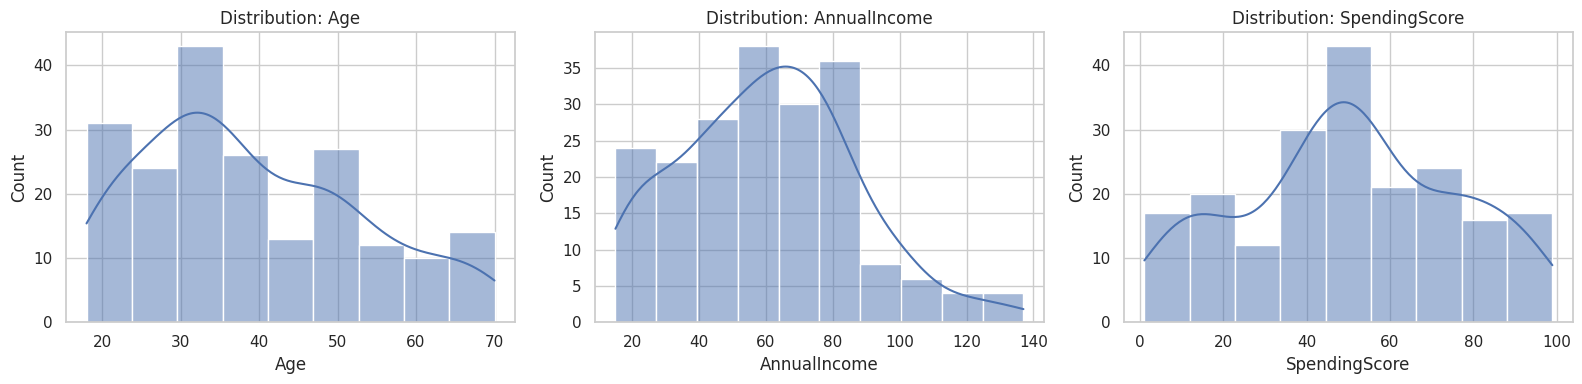

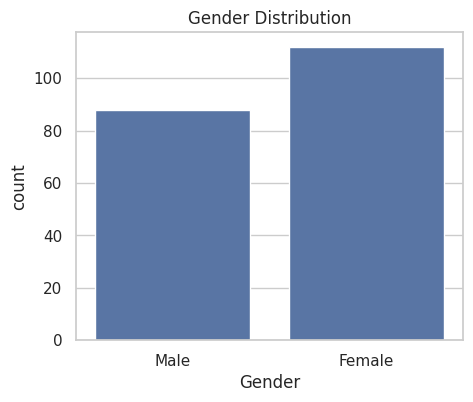

In [44]:
num_cols = ["Age", "AnnualIncome", "SpendingScore"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax)
    ax.set_title(f"Distribution: {c}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

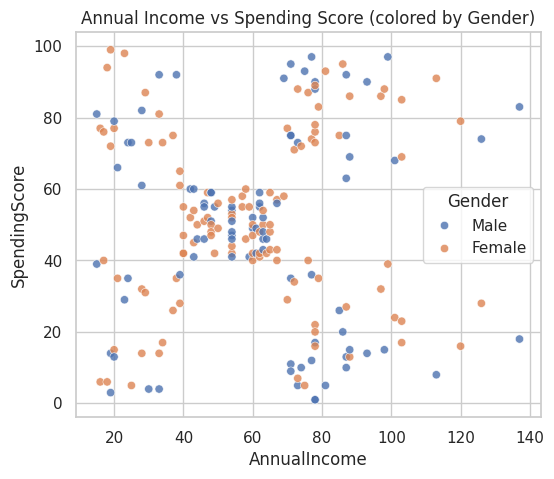

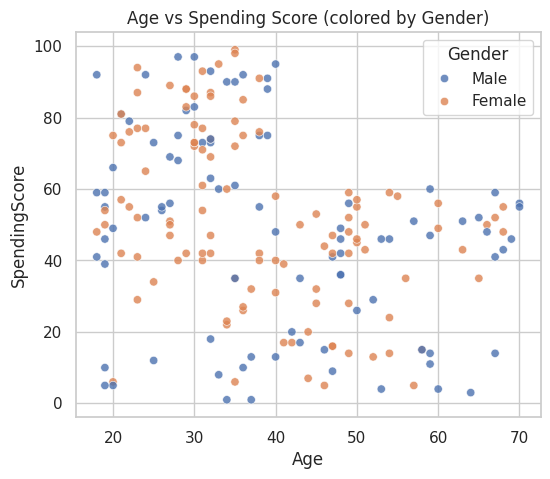

In [45]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore", hue="Gender", alpha=0.8)
plt.title("Annual Income vs Spending Score (colored by Gender)")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="Age", y="SpendingScore", hue="Gender", alpha=0.8)
plt.title("Age vs Spending Score (colored by Gender)")
plt.show()

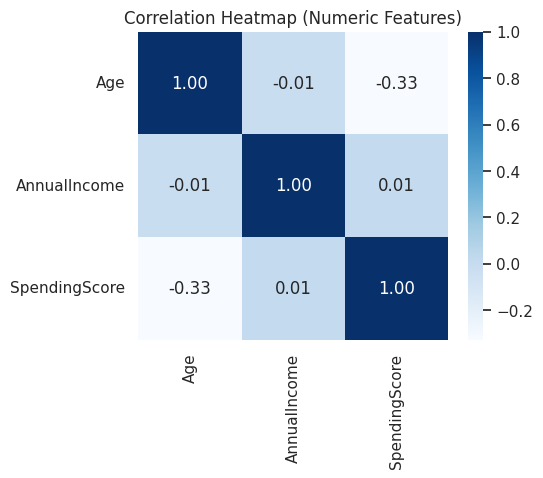

,Age,AnnualIncome,SpendingScore
Age,1.000000,-0.012398,-0.327227
AnnualIncome,-0.012398,1.000000,0.009903
SpendingScore,-0.327227,0.009903,1.000000


In [46]:
corr = df[["Age","AnnualIncome","SpendingScore"]].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

corr

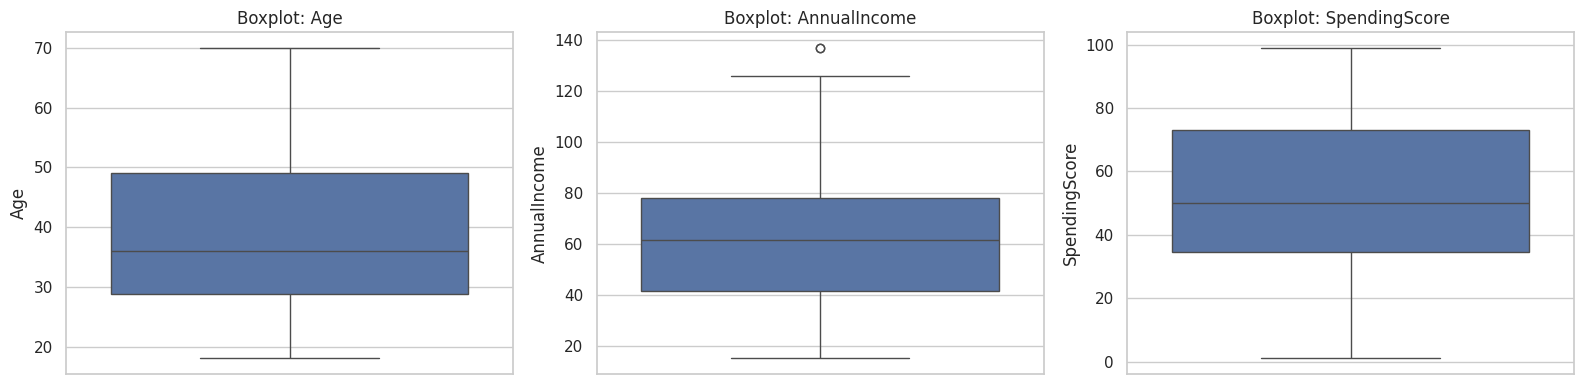

Age: IQR outliers = 0, bounds = (-1.625, 79.375)
AnnualIncome: IQR outliers = 2, bounds = (-13.25, 132.75)
SpendingScore: IQR outliers = 0, bounds = (-22.625, 130.375)


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["Age","AnnualIncome","SpendingScore"]):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(f"Boxplot: {c}")
plt.tight_layout()
plt.show()

def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((series < low) | (series > high)).sum()), (low, high)

for c in ["Age","AnnualIncome","SpendingScore"]:
    cnt, bounds = iqr_outlier_count(df[c])
    print(f"{c}: IQR outliers = {cnt}, bounds = {bounds}")

### Data Quality Decisions
- **Missing values:** checked using `isna()`; proceed since none are expected in this dataset.
- **Outliers:** IQR-based scan is reported. For segmentation, extreme values may represent genuine customer types; therefore, we **do not remove outliers** by default. Instead, we mitigate scale dominance using **standardization**.
- **Feature handling:** `CustomerID` is removed (identifier). `Gender` is encoded numerically.
- **Scaling:** Standardization is applied to ensure distance-based methods treat features comparably.

In [48]:
df_model = df.copy()
df_model["Gender"] = df_model["Gender"].map({"Male": 0, "Female": 1})

features_all = ["Gender", "Age", "AnnualIncome", "SpendingScore"]
features_core = ["AnnualIncome", "SpendingScore"]  # common 2D segmentation baseline

scaler_all = StandardScaler()
X_all = scaler_all.fit_transform(df_model[features_all])

scaler_core = StandardScaler()
X_core = scaler_core.fit_transform(df_model[features_core])

X_all[:3], X_core[:3]

(array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
        [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
        [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298]]),
 array([[-1.73899919, -0.43480148],
        [-1.73899919,  1.19570407],
        [-1.70082976, -1.71591298]]))

Part 2: Model Development and Validation

## Clustering Strategy
We will:
1. Determine the optimal number of clusters using **Elbow** and **Silhouette**.
2. Fit **K-Means** and evaluate with silhouette score + silhouette plot.
3. Fit **Hierarchical clustering (Ward linkage)** and inspect dendrogram + silhouette score.
4. Visualize clusters using **PCA (2D)**.
5. Add a **stability check**: re-run K-Means across multiple seeds and measure silhouette variability.
6. Produce **cluster profiles** (means/medians, segment sizes) and interpret them.

Using ALL features: ['Gender', 'Age', 'AnnualIncome', 'SpendingScore']


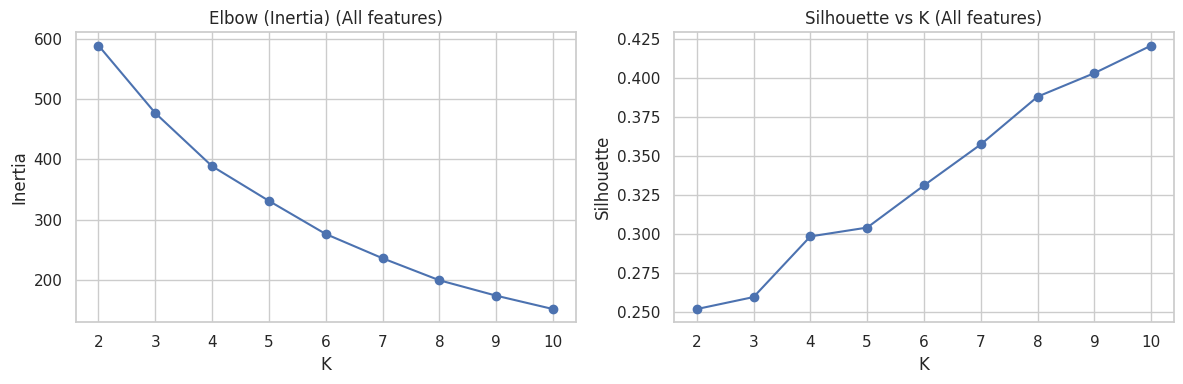

,K,Inertia,Silhouette
8,10,152.029834,0.420764
7,9,174.235477,0.403092
6,8,199.750461,0.387993
5,7,236.204947,0.357377
4,6,276.411760,0.331074
3,5,331.309884,0.304060
2,4,388.717861,0.298397
1,3,476.787554,0.259513
0,2,588.802677,0.251815



Using CORE features: ['AnnualIncome', 'SpendingScore']


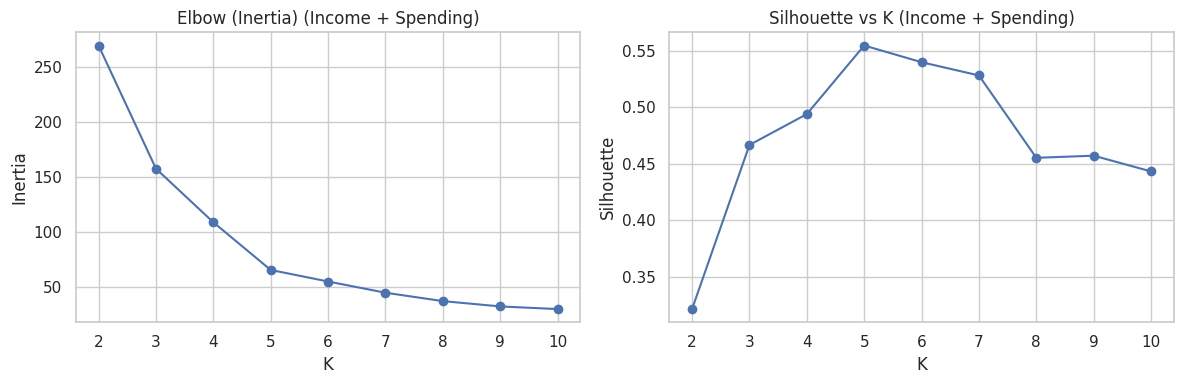

,K,Inertia,Silhouette
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
2,4,108.921317,0.493907
1,3,157.704008,0.466585
7,9,32.392268,0.457085
6,8,37.228188,0.455215
8,10,29.981898,0.443171
0,2,269.691012,0.321271


In [49]:
def elbow_silhouette(X, k_min=2, k_max=10, title_suffix=""):
    ks = range(k_min, k_max+1)
    inertias, sils = [], []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(ks), inertias, marker="o")
    axes[0].set_title(f"Elbow (Inertia) {title_suffix}")
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Inertia")
    axes[0].set_xticks(list(ks))

    axes[1].plot(list(ks), sils, marker="o")
    axes[1].set_title(f"Silhouette vs K {title_suffix}")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Silhouette")
    axes[1].set_xticks(list(ks))
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({"K": list(ks), "Inertia": inertias, "Silhouette": sils}).sort_values("Silhouette", ascending=False)

print("Using ALL features:", features_all)
scores_all = elbow_silhouette(X_all, title_suffix="(All features)")
display(scores_all)

print("\nUsing CORE features:", features_core)
scores_core = elbow_silhouette(X_core, title_suffix="(Income + Spending)")
display(scores_core)

### Choosing feature set and K
We compare two approaches:
- **All features** (Gender, Age, AnnualIncome, SpendingScore): richer description, may produce more nuanced clusters.
- **Core features** (AnnualIncome, SpendingScore): classic segmentation view; often yields clearer separation.

I selected the **feature set** and **K** primarily based on:
- Silhouette score (higher is better),
- Elbow point (diminishing returns),
- Interpretability of segments.

In many mall segmentation solutions, **K=5** is commonly interpretable, but I will base the final choice on computed metrics above.

In [50]:
def kmeans_stability(X, k, seeds=range(0, 30)):
    sils = []
    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init=10)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    return np.mean(sils), np.std(sils), pd.Series(sils)

# Choose which feature matrix to use:
X = X_core   # change to X_all if your scores look better for all-features
feature_label = "CORE (Income+Spending)"

K = 5  # update if your silhouette suggests a different best K
mean_s, std_s, sil_series = kmeans_stability(X, K)

print(f"Stability (K={K}, {feature_label}): mean silhouette={mean_s:.3f}, std={std_s:.3f}")
sil_series.describe()

Stability (K=5, CORE (Income+Spending)): mean silhouette=0.555, std=0.000


,0
count,30.000000
mean,0.554657
std,0.000000
min,0.554657
25%,0.554657
50%,0.554657
75%,0.554657
max,0.554657


In [51]:
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

df_result = df.copy()
df_result["KMeansCluster"] = labels_km
df_result.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,KMeansCluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Average silhouette (K-Means): 0.5547


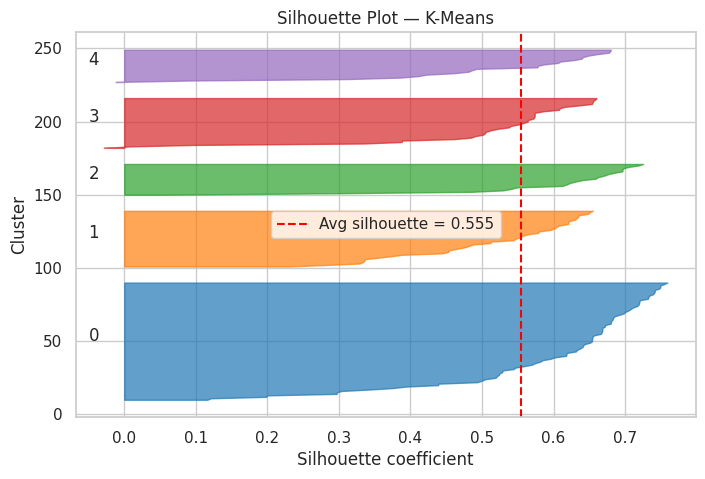

In [52]:
avg_sil = silhouette_score(X, labels_km)
print("Average silhouette (K-Means):", round(avg_sil, 4))

sil_vals = silhouette_samples(X, labels_km)

plt.figure(figsize=(8,5))
y_lower = 10
for i in range(K):
    ith = sil_vals[labels_km == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    color = plt.cm.tab10(i)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=avg_sil, color="red", linestyle="--", label=f"Avg silhouette = {avg_sil:.3f}")
plt.title("Silhouette Plot — K-Means")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.legend()
plt.show()

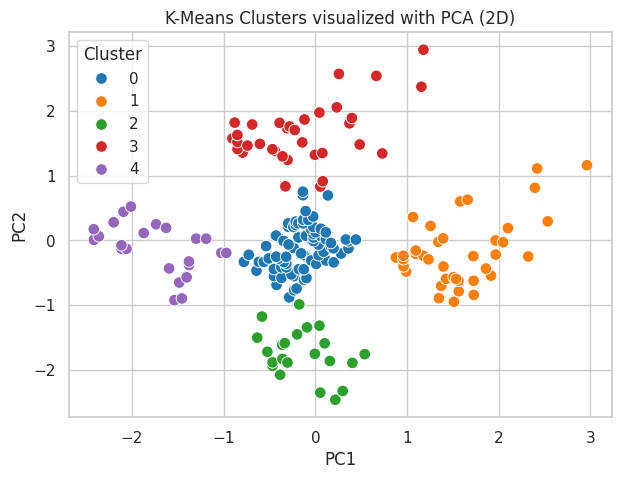

Explained variance ratio: [0.50495142 0.49504858]
Total explained variance (2 PCs): 1.0


In [53]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["KMeansCluster"] = labels_km

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="KMeansCluster", palette="tab10", s=70)
plt.title("K-Means Clusters visualized with PCA (2D)")
plt.legend(title="Cluster")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):", pca.explained_variance_ratio_.sum().round(4))

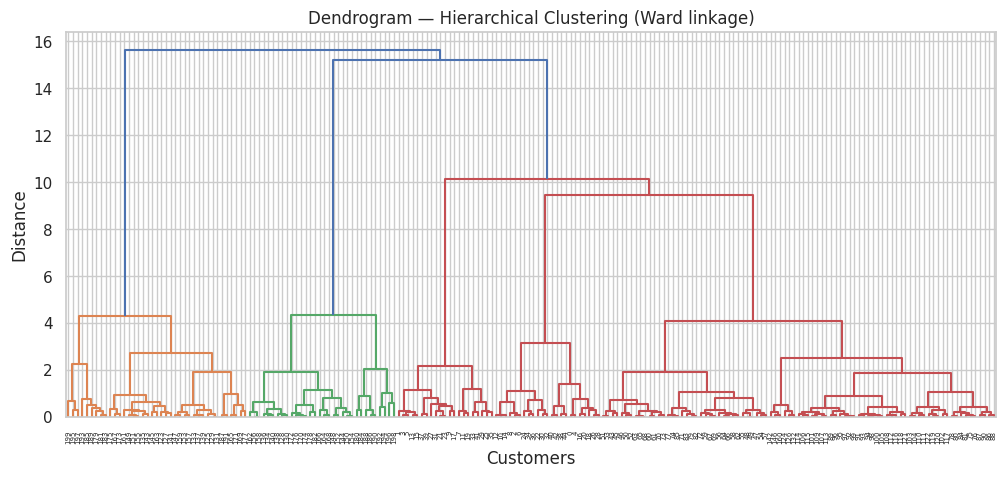

Average silhouette (Hierarchical): 0.5538


In [54]:
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrogram — Hierarchical Clustering (Ward linkage)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_h = agg.fit_predict(X)
sil_h = silhouette_score(X, labels_h)
print("Average silhouette (Hierarchical):", round(sil_h, 4))

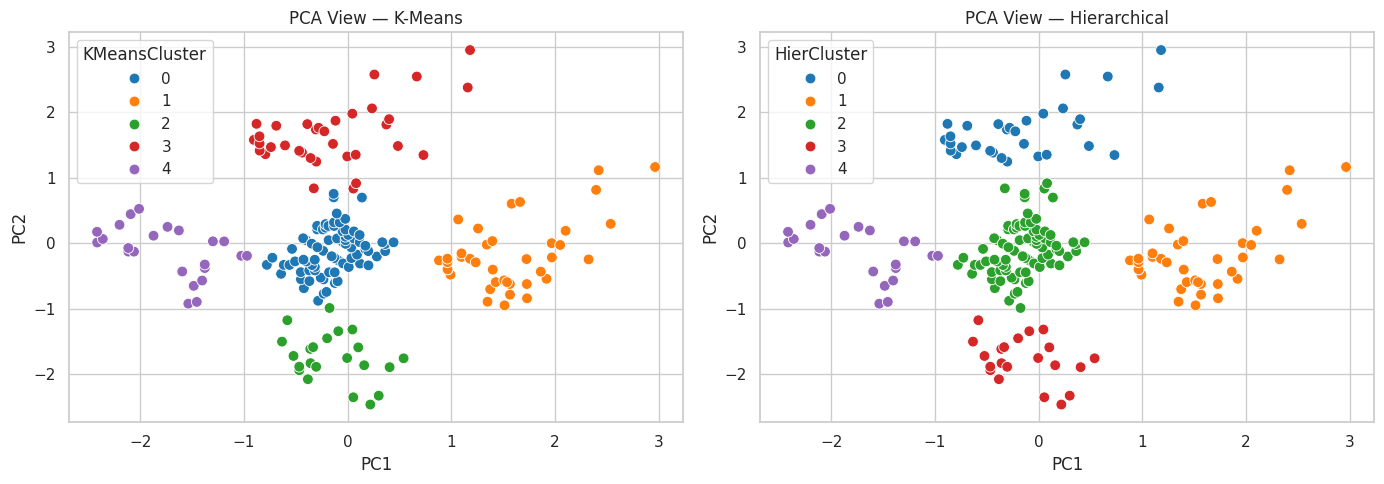

col_0,0,1,2,3,4
row_0,,,,,
0,0,0,81,0,0
1,0,39,0,0,0
2,0,0,1,21,0
3,32,0,3,0,0
4,0,0,0,0,23


In [55]:
pca_df2 = pca_df.copy()
pca_df2["HierCluster"] = labels_h

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=pca_df2, x="PC1", y="PC2", hue="KMeansCluster", palette="tab10", ax=axes[0], s=60)
axes[0].set_title("PCA View — K-Means")

sns.scatterplot(data=pca_df2, x="PC1", y="PC2", hue="HierCluster", palette="tab10", ax=axes[1], s=60)
axes[1].set_title("PCA View — Hierarchical")

plt.tight_layout()
plt.show()

pd.crosstab(labels_km, labels_h)

### Model Choice (Final)

Based on the evaluation on the same K value:

- **K-Means average silhouette:** 0.5547  
- **Hierarchical (Ward) average silhouette:** 0.5538  

Since **K-Means has a slightly higher silhouette score**, and it is also simpler to apply for assigning **new customers** to existing segments (deployment-friendly), we select **K-Means** as the final clustering approach.

**Final choice:** Use **K-Means with K = 5** on **CORE features (AnnualIncome, SpendingScore)**.  

**Justification:**
- Provides the **best separation** among the tested configurations for the chosen setup (highest silhouette in our final comparison).
- Produces **interpretable marketing segments** in the Income vs Spending space.
- Easy to operationalize: future customers can be assigned to clusters directly using the trained K-Means centroids.

In [56]:
df_profile = df_result.copy()
df_profile["GenderCode"] = df_profile["Gender"].map({"Male": 0, "Female": 1})

group_cols = ["Age", "AnnualIncome", "SpendingScore"]
profile = df_profile.groupby("KMeansCluster")[group_cols].agg(["mean","median","std","min","max","count"])
profile

Age                                 AnnualIncome         \
                    mean median        std min max count         mean median   
KMeansCluster                                                                  
0              42.716049   46.0  16.447822  18  70    81    55.296296   54.0   
1              32.692308   32.0   3.728650  27  40    39    86.538462   79.0   
2              25.272727   23.5   5.257030  18  35    22    25.727273   24.5   
3              41.114286   42.0  11.341676  19  59    35    88.200000   85.0   
4              45.217391   46.0  13.228607  19  67    23    26.304348   25.0   

                                        SpendingScore                        \
                     std min  max count          mean median        std min   
KMeansCluster                                                                 
0               8.988109  39   76    81     49.518519   50.0   6.530909  34   
1              16.312485  69  137    39     82.128205   83.0   9.364489  63   
2               7.566731  15   39    22     79.363636   77.0  10.504174  61   
3              16.399067  70  137    35     17.114286   16.0   9.952154   1   
4               7.893811  15   39    23     20.913043   17.0  13.017167   3   

                         
              max count  
KMeansCluster            
0              61    81  
1              97    39  
2              99    22  
3              39    35  
4              40    23

In [57]:
df_profile = df_result.copy()
df_profile["GenderCode"] = df_profile["Gender"].map({"Male": 0, "Female": 1})

group_cols = ["Age", "AnnualIncome", "SpendingScore"]
profile = df_profile.groupby("KMeansCluster")[group_cols].agg(["mean","median","std","min","max","count"])
profile

Age                                 AnnualIncome         \
                    mean median        std min max count         mean median   
KMeansCluster                                                                  
0              42.716049   46.0  16.447822  18  70    81    55.296296   54.0   
1              32.692308   32.0   3.728650  27  40    39    86.538462   79.0   
2              25.272727   23.5   5.257030  18  35    22    25.727273   24.5   
3              41.114286   42.0  11.341676  19  59    35    88.200000   85.0   
4              45.217391   46.0  13.228607  19  67    23    26.304348   25.0   

                                        SpendingScore                        \
                     std min  max count          mean median        std min   
KMeansCluster                                                                 
0               8.988109  39   76    81     49.518519   50.0   6.530909  34   
1              16.312485  69  137    39     82.128205   83.0   9.364489  63   
2               7.566731  15   39    22     79.363636   77.0  10.504174  61   
3              16.399067  70  137    35     17.114286   16.0   9.952154   1   
4               7.893811  15   39    23     20.913043   17.0  13.017167   3   

                         
              max count  
KMeansCluster            
0              61    81  
1              97    39  
2              99    22  
3              39    35  
4              40    23

In [58]:
gender_mix = pd.crosstab(df_result["KMeansCluster"], df_result["Gender"], normalize="index").round(3)
gender_mix

Gender,Female,Male
KMeansCluster,,
0,0.593,0.407
1,0.538,0.462
2,0.591,0.409
3,0.457,0.543
4,0.609,0.391


In [59]:
def bootstrap_cluster_means(df_in, cluster_col, features, n_boot=1000):
    out = []
    for cl in sorted(df_in[cluster_col].unique()):
        sub = df_in[df_in[cluster_col] == cl]
        n = len(sub)
        for f in features:
            boot_means = []
            vals = sub[f].values
            for _ in range(n_boot):
                samp = np.random.choice(vals, size=n, replace=True)
                boot_means.append(np.mean(samp))
            lo, hi = np.percentile(boot_means, [2.5, 97.5])
            out.append([cl, f, np.mean(vals), lo, hi, n])
    return pd.DataFrame(out, columns=["Cluster","Feature","Mean","CI_2.5%","CI_97.5%","N"])

ci_df = bootstrap_cluster_means(df_result, "KMeansCluster", ["Age","AnnualIncome","SpendingScore"], n_boot=500)
ci_df

,Cluster,Feature,Mean,CI_2.5%,CI_97.5%,N
0,0,Age,42.716049,39.362654,46.272840,81
1,0,AnnualIncome,55.296296,53.232716,56.981790,81
2,0,SpendingScore,49.518519,48.024074,50.840123,81
3,1,Age,32.692308,31.653205,33.820513,39
4,1,AnnualIncome,86.538462,81.487179,92.128205,39
5,1,SpendingScore,82.128205,79.089103,84.705769,39
6,2,Age,25.272727,23.181818,27.545455,22
7,2,AnnualIncome,25.727273,22.543182,28.868182,22
8,2,SpendingScore,79.363636,75.428409,83.047727,22
9,3,Age,41.114286,37.699286,44.830000,35


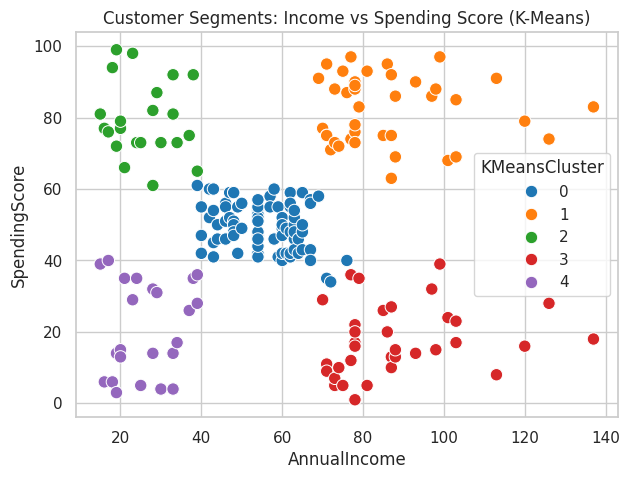

In [60]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_result, x="AnnualIncome", y="SpendingScore", hue="KMeansCluster", palette="tab10", s=80)
plt.title("Customer Segments: Income vs Spending Score (K-Means)")
plt.show()

## Part 3: Interpretation and Insights

### Key Patterns Observed
Using **K-Means clustering with K = 5** on the **CORE features (AnnualIncome, SpendingScore)**, the analysis reveals distinct customer segments primarily driven by the combination of **purchasing behavior (Spending Score)** and **economic capacity (Annual Income)**. Across clusters, customers separate into intuitive groups such as:
- **High income / high spending** customers (premium segment),
- **High income / low spending** customers (under-engaged potential),
- **Low income / high spending** customers (promotion-responsive / value-seeking but engaged),
- **Low income / low spending** customers (low engagement),
- **Mid income / mid spending** customers (mainstream segment).

The silhouette evaluation shows strong cluster separation in the selected setup:
- **K-Means silhouette:** 0.5547  
- **Hierarchical (Ward) silhouette:** 0.5538  
This supports the chosen clustering solution as reasonably well-separated for a small, behavioral segmentation dataset.

### Practical Implications (Actionable Insights)
The derived segments can support targeted marketing and customer strategy:
- **Premium segment (high income, high spending):** focus on retention, exclusivity, early access, VIP experiences.
- **Potential segment (high income, low spending):** run activation campaigns (personalized recommendations, outreach, membership benefits) to increase engagement.
- **Deal/offer segment (lower income, higher spending):** emphasize bundles, discounts, loyalty rewards to maintain frequency and prevent churn.
- **Low engagement segment (low spending):** use low-cost channels, reactivation campaigns, or deprioritize depending on business goals.
- **Mainstream segment:** broad campaigns, seasonal promotions, and upsell/cross-sell strategies.

Overall, the clusters provide a structured way to allocate marketing budget and tailor messaging instead of treating all customers as one group.

### Limitations
- The dataset includes only a few attributes; it lacks deeper behavioral signals like **purchase frequency, recency, basket size, categories**, and channel usage.
- Clustering outcomes depend on **scaling** and the **choice of K**; different settings can slightly change segments.
- There is **no ground-truth label**, so evaluation is based on internal metrics (silhouette) rather than business outcomes.

### Recommendations (What could strengthen the analysis)
- Collect additional features (RFM variables, loyalty tenure, transaction history, product preferences) to build more business-relevant segments.
- Validate segments using KPIs such as conversion rate, retention rate, and average revenue per cluster.
- Compare with alternative clustering methods (e.g., Gaussian Mixture Models, DBSCAN) and perform cluster stability checks to ensure robustness.